# Matter examples

This notebook integrates the `matter_*.py` demos from `examples/`, ordered by increasing complexity:

1. `matter_constant.py`
2. `matter_layer.py`
3. `matter_layer_mps.py`
4. `matter_prem.py`

Some grid sizes are reduced relative to the standalone scripts so the notebook remains practical to run interactively.

In [24]:
from pathlib import Path
import os
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

from nu_waves.globals.backend import Backend
from nu_waves.models.mixing import Mixing
from nu_waves.models.spectrum import Spectrum
from nu_waves.hamiltonian import matter, vacuum
from nu_waves.propagation.oscillator import Oscillator
from nu_waves.hamiltonian.matter import MatterProfile
from nu_waves.matter.prem import PREMModel
import nu_waves.utils.flavors as flavors
import nu_waves.utils.style

Backend.set_api(np)

try:
    import torch
except ImportError:
    torch = None

if torch is not None and getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
    TORCH_NOTEBOOK_DEVICE = "mps"
else:
    TORCH_NOTEBOOK_DEVICE = "cpu"


## Shared configuration

The sections below use the same active 3-flavor PMNS inputs and switch only the propagation model.

In [25]:
angles = {(1, 2): np.deg2rad(33.4), (1, 3): np.deg2rad(8.6), (2, 3): np.deg2rad(49)}
phases = {(1, 3): np.deg2rad(195)}
dm2_no = {(2, 1): 7.42e-5, (3, 2): 0.0024428}

def build_vacuum_hamiltonian(dm2_override=None, antineutrino=False):
    dm2_local = dict(dm2_no)
    if dm2_override is not None:
        dm2_local.update(dm2_override)
    return vacuum.Hamiltonian(
        mixing=Mixing(n_neutrinos=3, mixing_angles=angles, dirac_phases=phases),
        spectrum=Spectrum(n_neutrinos=3, m_lightest=0, dm2=dm2_local),
        antineutrino=antineutrino,
    )

def build_matter_hamiltonian(dm2_override=None, antineutrino=False):
    dm2_local = dict(dm2_no)
    if dm2_override is not None:
        dm2_local.update(dm2_override)
    return matter.Hamiltonian(
        mixing=Mixing(n_neutrinos=3, mixing_angles=angles, dirac_phases=phases),
        spectrum=Spectrum(n_neutrinos=3, m_lightest=0, dm2=dm2_local),
        antineutrino=antineutrino,
    )


## 1. Reproduction of `matter_constant.py`

We first compare vacuum propagation with constant-density matter, then compare normal ordering and inverted ordering in matter.

In [26]:
h_vacuum = build_vacuum_hamiltonian()
h_matter = build_matter_hamiltonian()
h_matter.set_constant_density(rho_in_g_per_cm3=0.0)
osc_constant = Oscillator(hamiltonian=h_vacuum)

E_min, E_max = 0.2, 6.0
E_check = np.linspace(E_min, E_max, 50)
P_vacuum_check = osc_constant.probability(
    L_km=295,
    E_GeV=E_check,
    flavor_emit=flavors.muon,
    flavor_det=flavors.electron,
)

osc_constant.hamiltonian = h_matter
P_zero_density = osc_constant.probability(
    L_km=295,
    E_GeV=E_check,
    flavor_emit=flavors.muon,
    flavor_det=flavors.electron,
)
np.testing.assert_allclose(np.abs(P_vacuum_check - P_zero_density), 0.0, atol=1e-7)
print("Zero-density matter matches vacuum.")

L_km = 1300.0
rho_gcm3, Ye = 2.8, 0.5
E_dune = np.linspace(E_min, E_max, 400)

osc_constant.hamiltonian = h_vacuum
P_mue_vac = osc_constant.probability(L_km=L_km, E_GeV=E_dune, flavor_emit=flavors.muon, flavor_det=flavors.electron)

osc_constant.hamiltonian = h_matter
h_matter.set_constant_density(rho_in_g_per_cm3=rho_gcm3, Ye=Ye)
h_matter.set_antineutrino(False)
P_mue_matter = osc_constant.probability(L_km=L_km, E_GeV=E_dune, flavor_emit=flavors.muon, flavor_det=flavors.electron)

h_matter.set_antineutrino(True)
P_muebar_matter = osc_constant.probability(L_km=L_km, E_GeV=E_dune, flavor_emit=flavors.muon, flavor_det=flavors.electron)


Zero-density matter matches vacuum.


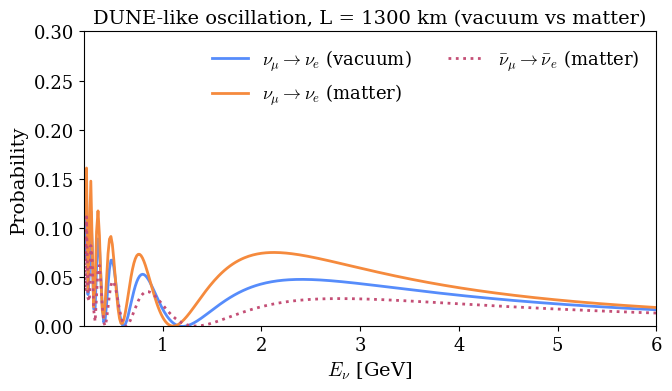

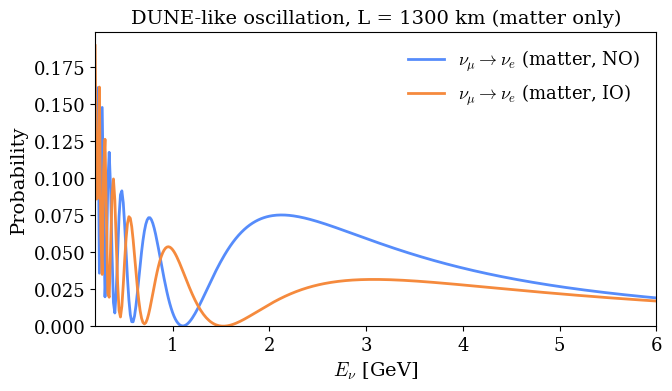

In [27]:
plt.figure(figsize=(7, 4.2))
plt.plot(E_dune, P_mue_vac, label=r"$\nu_\mu\to\nu_e$ (vacuum)", lw=2)
plt.plot(E_dune, P_mue_matter, label=r"$\nu_\mu\to\nu_e$ (matter)", lw=2)
plt.plot(E_dune, P_muebar_matter, ":", label=r"$\bar{\nu}_\mu\to\bar{\nu}_e$ (matter)", lw=2)
plt.xlabel(r"$E_\nu$ [GeV]")
plt.ylabel("Probability")
plt.title("DUNE-like oscillation, L = 1300 km (vacuum vs matter)")
plt.xlim(E_dune.min(), E_dune.max())
plt.ylim(0, 0.3)
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

h_matter.spectrum.set_dm2({(2, 1): 7.42e-5, (3, 2): -dm2_no[(3, 2)]})
h_matter.set_antineutrino(False)
P_mue_matter_io = osc_constant.probability(L_km=L_km, E_GeV=E_dune, flavor_emit=flavors.muon, flavor_det=flavors.electron)

plt.figure(figsize=(7, 4.2))
plt.plot(E_dune, P_mue_matter, label=r"$\nu_\mu\to\nu_e$ (matter, NO)", lw=2)
plt.plot(E_dune, P_mue_matter_io, label=r"$\nu_\mu\to\nu_e$ (matter, IO)", lw=2)
plt.xlabel(r"$E_\nu$ [GeV]")
plt.ylabel("Probability")
plt.title("DUNE-like oscillation, L = 1300 km (matter only)")
plt.xlim(E_dune.min(), E_dune.max())
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## 2. Reproduction of `matter_layer.py`

We now move to layered matter propagation: null-density parity with vacuum, unitarity checks, layer-order dependence, and parity with a one-layer constant-density profile.

In [28]:
h_layer = build_matter_hamiltonian()
h_vac_layer = build_vacuum_hamiltonian()
osc_layer = Oscillator(hamiltonian=h_layer)

E_layer = np.linspace(0.3, 3.0, 200)
P_vac_layer = Oscillator(hamiltonian=h_vac_layer).probability(
    L_km=295,
    E_GeV=E_layer,
    flavor_emit=flavors.muon,
    flavor_det=flavors.electron,
)

h_layer.set_matter_profile(MatterProfile.from_fractions([0.0], [0.5], [1.0]))
P_null_density = osc_layer.probability(
    L_km=295,
    E_GeV=E_layer,
    flavor_emit=flavors.muon,
    flavor_det=flavors.electron,
)
np.testing.assert_allclose(P_vac_layer, P_null_density, atol=1e-12)
print("Layered null density matches vacuum.")

prof_AB = MatterProfile.from_fractions([2.8, 11.0], [0.5, 0.467], [0.7, 0.3])
h_layer.set_matter_profile(prof_AB)
P_full_layer = osc_layer.probability(L_km=1000, E_GeV=np.linspace(0.3, 5.0, 120), flavor_emit=None, flavor_det=None)
np.testing.assert_allclose(P_full_layer.sum(axis=-2), 1.0, atol=2e-6)
print("Layered profile unitarity check passed.")

prof_BA = MatterProfile.from_fractions([11.0, 2.8], [0.467, 0.5], [0.3, 0.7])
h_layer.set_matter_profile(prof_AB)
P_AB = osc_layer.probability(L_km=1000, E_GeV=np.linspace(0.3, 5.0, 200), flavor_emit=flavors.muon, flavor_det=flavors.electron)
h_layer.set_matter_profile(prof_BA)
P_BA = osc_layer.probability(L_km=1000, E_GeV=np.linspace(0.3, 5.0, 200), flavor_emit=flavors.muon, flavor_det=flavors.electron)
max_diff_layers = np.max(np.abs(P_AB - P_BA))
print(f"Maximum AB/BA difference: {max_diff_layers:.4e}")
assert max_diff_layers > 1e-3

L_dune_layer = 1300.0
E_dune_layer = np.linspace(0.3, 5.0, 250)
rho_layer, Ye_layer = 2.8, 0.5

h_constant_density = build_matter_hamiltonian()
h_constant_density.set_constant_density(rho_in_g_per_cm3=rho_layer, Ye=Ye_layer)
P_constant_density = Oscillator(hamiltonian=h_constant_density).probability(
    L_km=L_dune_layer,
    E_GeV=E_dune_layer,
    flavor_emit=None,
    flavor_det=None,
)

h_one_layer = build_matter_hamiltonian()
h_one_layer.set_matter_profile(MatterProfile.from_fractions([rho_layer], [Ye_layer], [1.0]))
P_one_layer = Oscillator(hamiltonian=h_one_layer).probability(
    L_km=L_dune_layer,
    E_GeV=E_dune_layer,
    flavor_emit=None,
    flavor_det=None,
)
np.testing.assert_allclose(P_constant_density, P_one_layer, atol=1e-10)
print("One-layer profile reproduces the constant-density result.")


Layered null density matches vacuum.
Layered profile unitarity check passed.
Maximum AB/BA difference: 2.6428e-02
One-layer profile reproduces the constant-density result.


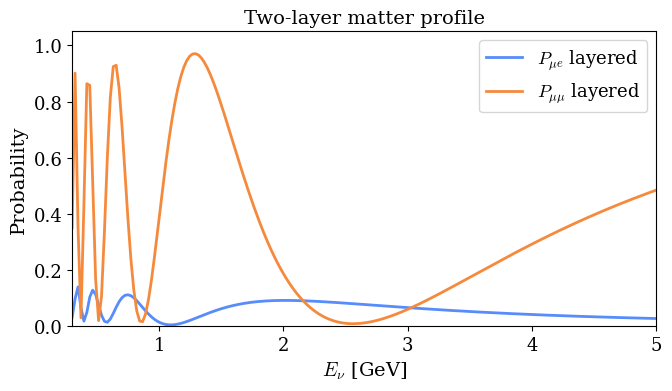

In [29]:
E_plot_layer = np.linspace(0.3, 5.0, 200)
h_layer.set_matter_profile(prof_AB)
P_mue_layer = osc_layer.probability(L_km=1300.0, E_GeV=E_plot_layer, flavor_emit=flavors.muon, flavor_det=flavors.electron)
P_mumu_layer = osc_layer.probability(L_km=1300.0, E_GeV=E_plot_layer, flavor_emit=flavors.muon, flavor_det=flavors.muon)

plt.figure(figsize=(7, 4.2))
plt.plot(E_plot_layer, P_mue_layer, label=r"$P_{\mu e}$ layered", lw=2)
plt.plot(E_plot_layer, P_mumu_layer, label=r"$P_{\mu\mu}$ layered", lw=2)
plt.xlabel(r"$E_\nu$ [GeV]")
plt.ylabel("Probability")
plt.title("Two-layer matter profile")
plt.xlim(E_plot_layer.min(), E_plot_layer.max())
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


## 3. Reproduction of `matter_layer_mps.py`

This section compares a layered matter calculation on the NumPy backend against the Torch backend when Torch is available.

In [30]:
Backend.set_api(np)
h_numpy_mps = build_matter_hamiltonian()
osc_numpy_mps = Oscillator(hamiltonian=h_numpy_mps)
prof_mps = MatterProfile.from_fractions([2.8, 11.0], [0.50, 0.467], [0.7, 0.3])
h_numpy_mps.set_matter_profile(prof_mps)

L_mps = 1300.0
E_mps = np.linspace(0.3, 5.0, 240)
P_full_numpy = osc_numpy_mps.probability(L_km=L_mps, E_GeV=E_mps, flavor_emit=None, flavor_det=None)
P_mue_numpy = osc_numpy_mps.probability(L_km=L_mps, E_GeV=E_mps, flavor_emit=flavors.muon, flavor_det=flavors.electron)
P_mumu_numpy = osc_numpy_mps.probability(L_km=L_mps, E_GeV=E_mps, flavor_emit=flavors.muon, flavor_det=flavors.muon)
np.testing.assert_allclose(P_full_numpy.sum(axis=-2), 1.0, atol=2e-6)
print("NumPy layered unitarity check passed.")

if torch is None:
    print("Torch is not available. Skipping backend parity test.")
else:
    Backend.set_api(torch, device=TORCH_NOTEBOOK_DEVICE)
    print(f"Torch backend device: {TORCH_NOTEBOOK_DEVICE}")
    h_torch_mps = build_matter_hamiltonian()
    h_torch_mps.set_matter_profile(prof_mps)
    osc_torch_mps = Oscillator(hamiltonian=h_torch_mps)
    P_mue_torch = osc_torch_mps.probability(L_km=L_mps, E_GeV=E_mps, flavor_emit=flavors.muon, flavor_det=flavors.electron)
    P_mumu_torch = osc_torch_mps.probability(L_km=L_mps, E_GeV=E_mps, flavor_emit=flavors.muon, flavor_det=flavors.muon)
    np.testing.assert_allclose(P_mue_numpy, P_mue_torch, rtol=5e-4, atol=5e-5)
    np.testing.assert_allclose(P_mumu_numpy, P_mumu_torch, rtol=5e-4, atol=5e-5)
    print("Torch layered parity: OK")
    Backend.set_api(np)


NumPy layered unitarity check passed.
[Torch] Using device: mps
Torch backend device: mps
Torch layered parity: OK


## 4. Reproduction of `matter_prem.py`

This final section uses a PREM Earth model and computes neutrino and antineutrino oscillation probabilities across a grid in energy and zenith angle. The grid is reduced here for notebook interactivity.

In [31]:
Backend.set_api(np)
E_prem = np.logspace(-1, 2, 120)
cosz_binning = np.linspace(-1.0, 1.0, 120)
prem = PREMModel()
SCHEME = "hist_density"
n_bins_layers = 300
n_bins_density = 60

h_prem = build_matter_hamiltonian()
osc_prem = Oscillator(hamiltonian=h_prem)

cosz_profile = prem.profile_from_coszen(+0.3, h_atm_km=15.0)
print("L_tot(downgoing) =", sum(layer.weight for layer in cosz_profile.layers))
for cosz in (-1e-3, +1e-3):
    cosz_profile = prem.profile_from_coszen(cosz, h_atm_km=15.0)
    print(cosz, "L_atm =", sum(layer.weight for layer in cosz_profile.layers if layer.rho_in_g_per_cm3 == 0.0))

P_mue = np.zeros((len(cosz_binning), len(E_prem)))
P_mumu = np.zeros_like(P_mue)
P_mue_bar = np.zeros_like(P_mue)
P_mumu_bar = np.zeros_like(P_mue)

t0 = time.perf_counter()
for iy, cosz in enumerate(cosz_binning):
    cosz_profile = prem.profile_from_coszen(
        cosz,
        scheme=SCHEME,
        n_bins=n_bins_layers,
        nbins_density=n_bins_density,
        merge_tol=0.0,
        h_atm_km=15.0,
    )
    h_prem.set_matter_profile(cosz_profile)
    L_tot = float(sum(layer.weight for layer in cosz_profile.layers))

    osc_prem.hamiltonian.set_antineutrino(False)
    P_mu_i = osc_prem.probability(L_km=L_tot, E_GeV=E_prem, flavor_emit=flavors.muon, flavor_det=[flavors.electron, flavors.muon])

    osc_prem.hamiltonian.set_antineutrino(True)
    P_mubar_i = osc_prem.probability(L_km=L_tot, E_GeV=E_prem, flavor_emit=flavors.muon, flavor_det=[flavors.electron, flavors.muon])

    P_mue[iy], P_mumu[iy] = P_mu_i[..., 0], P_mu_i[..., 1]
    P_mue_bar[iy], P_mumu_bar[iy] = P_mubar_i[..., 0], P_mubar_i[..., 1]
t1 = time.perf_counter()
print(f"Computation time: {t1 - t0:.3f} s")

E_edges = np.geomspace(E_prem.min(), E_prem.max(), E_prem.size + 1)
CZ_edges = np.linspace(cosz_binning.min(), cosz_binning.max(), cosz_binning.size + 1)


L_tot(downgoing) = 49.41994175608875
-0.001 L_atm = 431.1168165625588
0.001 L_atm = 431.1168165625588
Computation time: 0.953 s


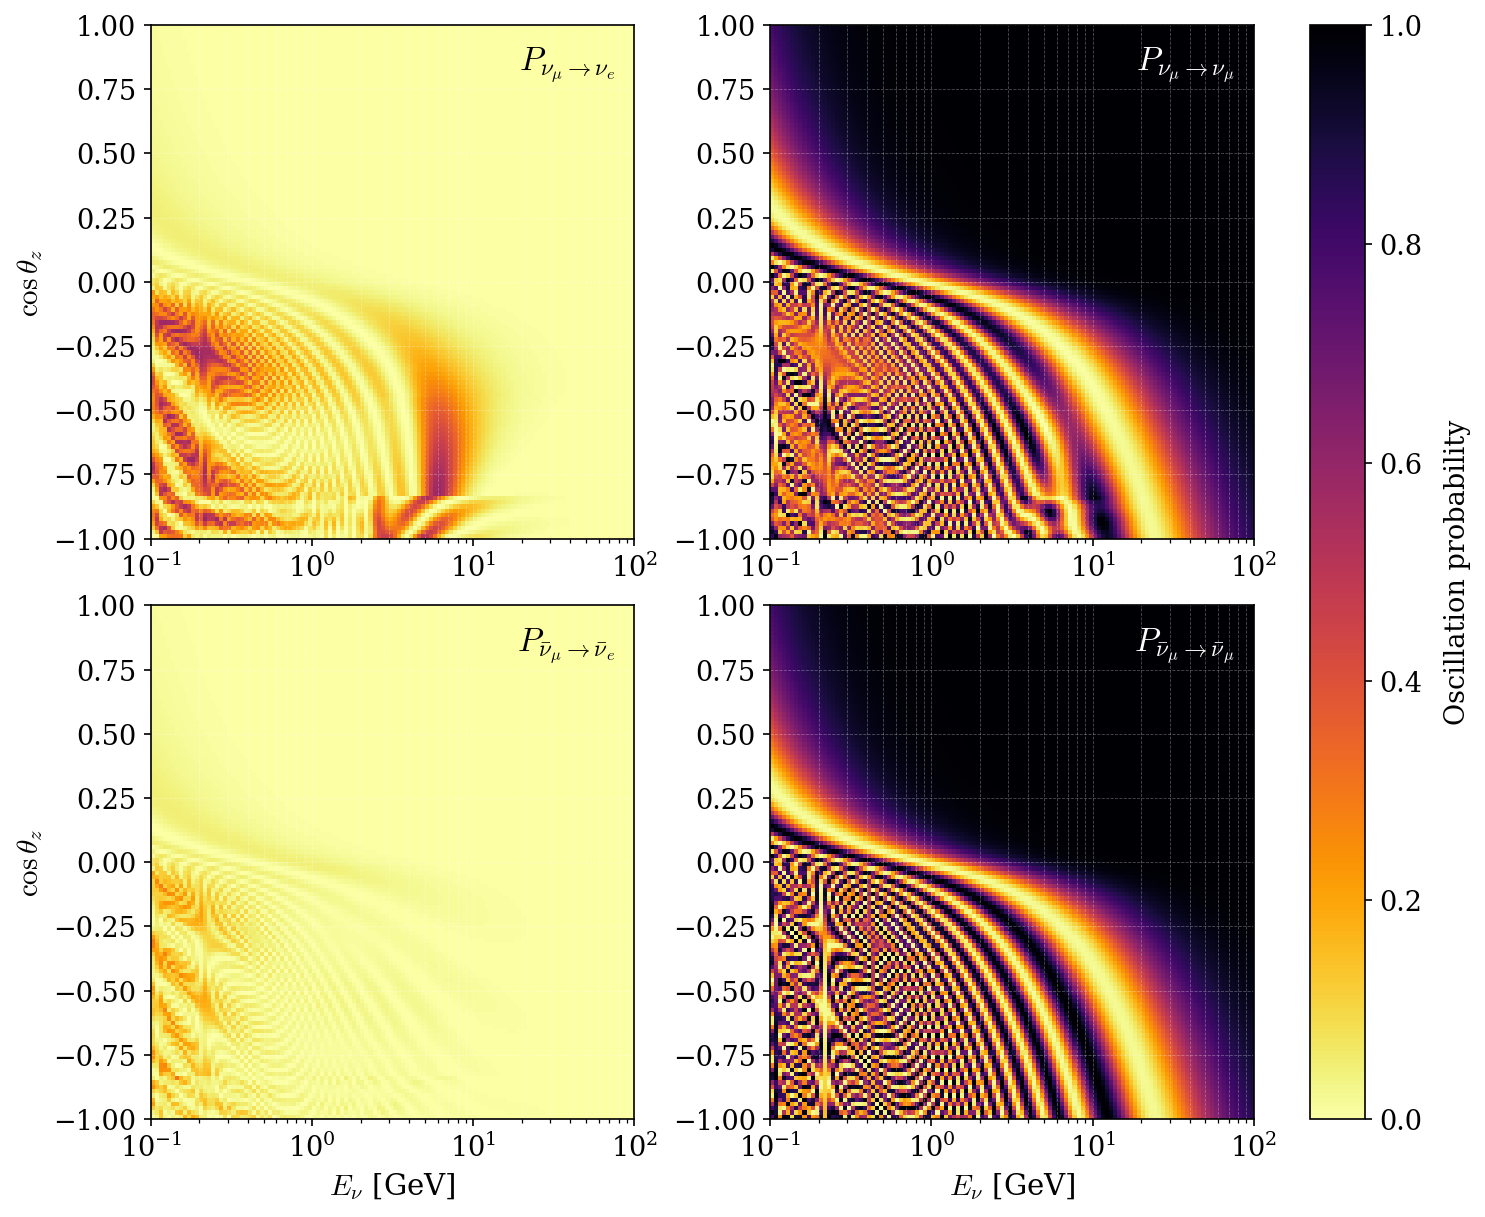

In [32]:
def draw_panel(ax, Z, label_tex, text_color, fontsize=16):
    pc = ax.pcolormesh(
        E_edges,
        CZ_edges,
        Z,
        vmin=0.0,
        vmax=1.0,
        shading="auto",
        cmap="inferno_r",
    )
    ax.set_xscale("log")
    ax.grid(True, which="both", color="w", alpha=0.3, lw=0.4, ls="--")
    ax.text(0.96, 0.96, label_tex, transform=ax.transAxes, ha="right", va="top", color=text_color, fontsize=fontsize, weight="bold")
    return pc

fig, axs = plt.subplots(2, 2, figsize=(9.8, 8.0), dpi=150, constrained_layout=True)
m0 = draw_panel(axs[0, 0], P_mue, r"$P_{\nu_\mu \rightarrow \nu_e}$", "black")
_ = draw_panel(axs[0, 1], P_mumu, r"$P_{\nu_\mu \rightarrow \nu_\mu}$", "white")
_ = draw_panel(axs[1, 0], P_mue_bar, r"$P_{\bar{\nu}_\mu \rightarrow \bar{\nu}_e}$", "black")
_ = draw_panel(axs[1, 1], P_mumu_bar, r"$P_{\bar{\nu}_\mu \rightarrow \bar{\nu}_\mu}$", "white")

for ax in axs[0, :]:
    ax.set_xlabel("")
for ax in axs[:, 1]:
    ax.set_ylabel("")
for ax in axs[1, :]:
    ax.set_xlabel(r"$E_\nu$ [GeV]")
for ax in axs[:, 0]:
    ax.set_ylabel(r"$\cos\theta_z$")

cbar = fig.colorbar(m0, ax=axs, location="right", fraction=0.05, pad=0.03)
cbar.set_label("Oscillation probability", labelpad=10, fontsize=13)
plt.show()
